**RAA: DEEP LEARNING: PARTE 2**

Empezamos con la importacion de todas las libreriass y fubnciones necesarias para todo el pipline

In [1]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from PIL import Image
from tqdm.auto import tqdm

from google.colab import drive
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accedemos a la ruta donde tenemos cargadas nuestras imágenes en Google Drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive



##PREPROCESAMIENTO:
Empezamos definiendo la clase encargada de hacer el preprocesamiento de las imágenes:

antes de realizar el preprcesamiento de todas las imágenes del dataset, mostramos el efecto de este en una sola imágen:

Número de imágenes encontradas: 6504

IMAGEN ORIGINAL
Tamaño: (1244, 1244)
Modo: L

IMAGEN PREPROCESADA
Shape tensor: torch.Size([3, 256, 256])


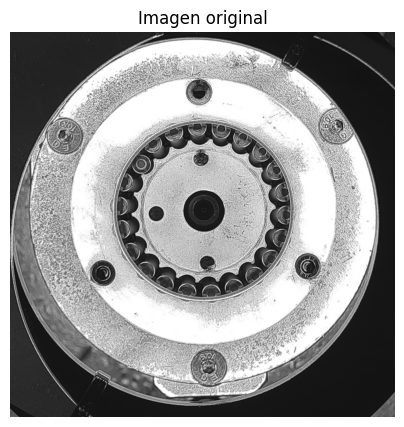

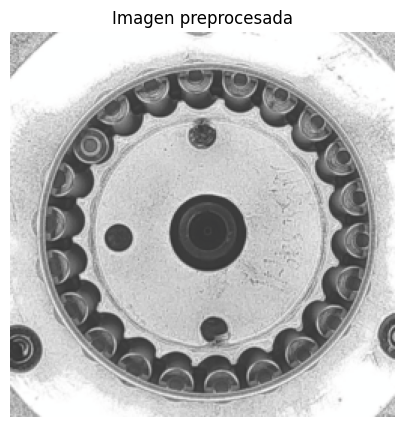

In [ ]:
INPUT_DIR = "/content/drive/MyDrive/datasets/Train_bearing_images"
OUTPUT_DIR = "/content/drive/MyDrive/datasets/TrainBearingPreprocess"

dataset = Preprocessing(root_dir=INPUT_DIR, image_size=256)


#para hacer una idea de cómo funciona el preprocesamiento mostramoso una imagen del dataset antes y despues
raw_path = dataset.image_paths[0]
raw_image = Image.open(raw_path)

print("\nIMAGEN ORIGINAL")
print("Tamaño:", raw_image.size)
print("Modo:", raw_image.mode)

plt.figure(figsize=(5,5))
plt.imshow(raw_image, cmap='gray')
plt.title("Imagen original")
plt.axis("off")

processed_image, path = dataset[0]

print("\nIMAGEN PREPROCESADA")
print("Shape tensor:", processed_image.shape)

# Desnormalizar inline (sin función)
img = processed_image.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Imagen preprocesada")
plt.axis("off")

plt.show()

A continuación, definimos el modelo de entrenamiento que vamos a usar



##DEFINICIÓN DEL MODELO:

Ahora definimos el modelo preentrenado que se va a usar, en este caso será WideResNet50, entrenado sobre el dataset ImageNet

In [5]:
class WideResNet50FeatureExtractor(nn.Module):

    def __init__(self, unfreeze_last_layer=True):
        super().__init__()
        backbone = models.wide_resnet50_2(
            weights=models.Wide_ResNet50_2_Weights.DEFAULT
        )


        self.stem = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3

        # congelamos todos los pesos
        for param in self.parameters():
            param.requires_grad = False

        #dejamos descongelada la última capa, para hacer fine-turing
        if unfreeze_last_layer:
            for param in self.layer3.parameters():
                param.requires_grad = True

    def forward(self, x):
        x = self.stem(x)
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        return [f1, f2, f3]

En esta celda se define la clase FeatureAdapter, cuya función es adaptar las características extraídas por un modelo preentrenado antes de ser procesadas por el modelo de flujo.

Para ello, utiliza una combinación de convoluciones (1×1 y 3×3), seguidas de normalización (Batch Normalization) y funciones de activación (ReLU), lo que permite mejorar la estabilidad y la capacidad de representación de las características.

In [6]:
class FeatureAdapter(nn.Module):

    def __init__(self, in_channels, hidden_channels=None, out_channels=None):
        super().__init__()
        hidden_channels = hidden_channels or in_channels
        out_channels = out_channels or in_channels


        self.adapter = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.adapter(x)

Seguimos con la definición de todos los bloque fundamentales de nuestro modelo las componentes de nuestro modelo:

La clase ConvSubNet define una pequeña red convolucional que actúa como subred dentro del acoplamiento afín. Su función es predecir los parámetros de escala (s) y traslación (t) a partir de una parte de la entrada. La última capa se inicializa a cero para estabilizar el entrenamiento al inicio.

La clase Invertible1x1Conv implementa una convolución 1x1 invertible, cuya función es mezclar los canales de la entrada de manera reversible. Se inicializa como una matriz ortogonal para garantizar su invertibilidad y permite calcular eficientemente el determinante del Jacobiano, necesario para el entrenamiento basado en máxima verosimilitud.

Por último, la clase AffineCoupling define una capa de acoplamiento afín, que divide los canales de la entrada en dos partes. Una de ellas se mantiene fija, mientras que la otra se transforma mediante una operación afín cuyos parámetros son generados por la subred convolucional. Este bloque es clave en los modelos de flujo, ya que permite construir transformaciones complejas manteniendo la invertibilidad y un cálculo tractable del Jacobiano.

In [7]:
class ConvSubNet(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels * 2, kernel_size=3, padding=1)
        )

        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


class Invertible1x1Conv(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        w_init = torch.linalg.qr(torch.randn(num_channels, num_channels)).Q
        self.weight = nn.Parameter(w_init)

    def forward(self, x):
        B, C, H, W = x.shape
        weight = self.weight.view(C, C, 1, 1)
        z = F.conv2d(x, weight)
        logdet = H * W * torch.slogdet(self.weight)[1]
        return z, logdet

    def inverse(self, z):
        C = z.shape[1]
        w_inv = torch.inverse(self.weight).view(C, C, 1, 1)
        return F.conv2d(z, w_inv)



class AffineCoupling(nn.Module):
    def __init__(self, channels, hidden_channels=128):
        super().__init__()
        if channels % 2 != 0:
            raise ValueError("El número de canales debe ser par.")
        self.half_channels = channels // 2
        self.nn_scale_shift = ConvSubNet(self.half_channels, hidden_channels)

    def forward(self, x):
        x_a, x_b = torch.chunk(x, 2, dim=1)
        h = self.nn_scale_shift(x_a)
        s, t = torch.chunk(h, 2, dim=1)
        s = torch.tanh(s)
        z_b = x_b * torch.exp(s) + t
        z = torch.cat([x_a, z_b], dim=1)
        logdet = torch.sum(s, dim=(1, 2, 3))
        return z, logdet

    def inverse(self, z):
        z_a, z_b = torch.chunk(z, 2, dim=1)
        h = self.nn_scale_shift(z_a)
        s, t = torch.chunk(h, 2, dim=1)
        s = torch.tanh(s)
        x_b = (z_b - t) * torch.exp(-s)
        return torch.cat([z_a, x_b], dim=1)

En esta celda se definen los bloques que componen el flujo normalizante. La clase FlowStep representa un paso del flujo, combinando una convolución 1×1 invertible y una capa de acoplamiento afín, permitiendo transformar las características de forma reversible y calcular el log-determinante del Jacobiano.

Por su parte, FlowBranch agrupa varios de estos pasos de manera secuencial, formando una cadena de transformaciones más compleja. Durante el forward, aplica cada paso acumulando el log-determinante total, necesario para el cálculo de la función de pérdida en el entrenamiento.En esta celda se definen los bloques que componen el flujo normalizante.

In [8]:
class FlowStep(nn.Module):
    def __init__(self, channels, hidden_channels=128):
        super().__init__()
        self.invconv = Invertible1x1Conv(channels)
        self.coupling = AffineCoupling(channels, hidden_channels)


    def forward(self, x):
        x, logdet1 = self.invconv(x)
        x, logdet2 = self.coupling(x)
        if isinstance(logdet1, torch.Tensor) and logdet1.dim() == 0:
            logdet1 = logdet1.expand(x.shape[0])
        return x, logdet1 + logdet2


    def inverse(self, z):
        z = self.coupling.inverse(z)
        return self.invconv.inverse(z)


class FlowBranch(nn.Module):
    def __init__(self, channels, num_steps=8, hidden_channels=128):
        super().__init__()
        self.steps = nn.ModuleList([
            FlowStep(channels, hidden_channels) for _ in range(num_steps)
        ])


    def forward(self, x):
        total_logdet = torch.zeros(x.shape[0], device=x.device)
        for step in self.steps:
            x, logdet = step(x)
            total_logdet += logdet
        return x, total_logdet


En esta celda se define la arquitectura completa del modelo FastFlow. El modelo combina un extractor de características preentrenado (backbone), varios módulos adaptadores y múltiples ramas de flujo normalizante aplicadas a diferentes niveles de características.

Cada mapa de características extraído es primero adaptado mediante un FeatureAdapter y posteriormente transformado por un FlowBranch, que modela su distribución mediante normalizing flows. La función forward calcula la probabilidad logarítmica de las variables latentes bajo una distribución gaussiana y la combina con el log-determinante del flujo para obtener la verosimilitud de los datos.

Finalmente, la pérdida se define como la suma de las pérdidas negativas de log-verosimilitud de cada nivel de características, promediada sobre el batch, lo que permite entrenar el modelo para detectar anomalías.

In [30]:
class FastFlow(nn.Module):
    def __init__(
        self,
        flow_steps=6,
        flow_hidden_channels=256,
        adapter_hidden_channels=(256, 512, 1024),
        unfreeze_last_layer=True):

        super().__init__()
        self.backbone = WideResNet50FeatureExtractor(unfreeze_last_layer)

        self.adapters = nn.ModuleList([
            FeatureAdapter(256, adapter_hidden_channels[0], 256),
            FeatureAdapter(512, adapter_hidden_channels[1], 512),
            FeatureAdapter(1024, adapter_hidden_channels[2], 1024),
        ])

        self.flow_branches = nn.ModuleList([
            FlowBranch(256, flow_steps, flow_hidden_channels),
            FlowBranch(512, flow_steps, flow_hidden_channels),
            FlowBranch(1024, flow_steps, flow_hidden_channels),
        ])

    @staticmethod
    def gaussian_log_prob(z,):
        log_z = -0.5 * (z ** 2 + math.log(2 * math.pi))
        return torch.sum(log_z, dim=(1, 2, 3))

    def forward(self, x):
        features = self.backbone(x)
        losses = []

        for feat, adapter, flow in zip(features, self.adapters, self.flow_branches):
            feat_adapted = adapter(feat)
            z, logdet = flow(feat_adapted)
            log_pz = self.gaussian_log_prob(z)
            log_px = log_pz + logdet
            loss = -log_px.mean()
            losses.append(loss)

        total_loss=sum(losses)
        return {"loss": total_loss}

    def anomaly_map(self, x, out_size=(256, 256)):
    with torch.no_grad():
        features = self.backbone(x)
        maps = []

        for feat, adapter, flow in zip(features, self.adapters, self.flow_branches):
            feat_adapted = adapter(feat)
            z, logdet = flow(feat_adapted)

            B, C, H, W = z.shape
            n_dims = C * H * W

            log_pz = -0.5 * (z ** 2 + math.log(2 * math.pi))  # [B, C, H, W]

            logdet_per_pixel = (logdet / n_dims).view(B, 1, 1, 1)  # [B, 1, 1, 1]

            log_px_map = torch.sum(log_pz, dim=1, keepdim=True) + logdet_per_pixel  # [B, 1, H, W]

            anomaly = -log_px_map

            anomaly = F.interpolate(
                anomaly,
                size=out_size,
                mode="bilinear",
                align_corners=False
            )
            maps.append(anomaly)

        combined = torch.mean(torch.stack(maps), dim=0)
        return combined

                maps.append(anomaly)

            combined = torch.mean(z**2, dim=0)
            return combined


##ENTRENAMIENTO DEL MODELO
Definimos la configuración del entrenamiento, donde se usarán batches 32 imágenes, se harán 10 pasadas completas en el conjunto de entrenamiento. Tambien fijamos una tase de aprendizaje baja para no escapar del miínimo absoluto

In [10]:
ROOT_DIR = "/content/drive/MyDrive/datasets/Train_bearing_images"

SAVE_DIR = "/content/drive/MyDrive/datasets/fastflow_checkpoints"os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_PATH = os.path.join(SAVE_DIR, "fastflow_wide_trained.pth")

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

Se empieza cargardo el dataset preprocesado donde  y definimos el entrenamiento del modelo con los parámetros anteriores, se define un Bucle principal de entrenamiento por épocas y finalmente se calcula la pérdida media por época.

In [ ]:
class BearingDataset(Dataset):
    def __init__(self, root_dir, image_size=256):
        self.root_dir = Path(root_dir)
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.image_paths = list(self.root_dir.glob("*.jpg"))
        print("Imágenes encontradas:", len(self.image_paths))

        if len(self.image_paths) == 0:
            raise ValueError(f"No se encontraron imágenes en {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")
        image = image.crop((285, 225, 950, 900))  # crop específico de tu dominio
        image = self.transform(image)
        return image, str(path)

In [11]:
dataset = BearingDataset(root_dir=ROOT_DIR, image_size=256)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, #mezclamos los datos para un mejor aprendizaje
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

#MODELO Y OPTIMIZADOR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #seleccionamos el dispositivo de entrenamientoprint("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Dispositivo de entrenamiento:", device)
model = FastFlow(
    flow_steps=6,
    flow_hidden_channels=256,
    adapter_hidden_channels=(256, 512, 1024),
    unfreeze_last_layer=True
).to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-6
)


#ENTRENAMIENTO
print("\nIniciando entrenamiento...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, paths in progress_bar:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()
        loss = model(images)["loss"]
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss Promedio: {avg_loss:.4f}")

    # Guardado por época
    epoch_save_path = os.path.join(SAVE_DIR, f"fastflow_epoch_{epoch}.pth")
    torch.save(model.state_dict(), epoch_save_path)
    print(f"Checkpoint guardado en: {epoch_save_path}")

# Guardado final
torch.save(model.state_dict(), SAVE_PATH)

print(f"\nEntrenamiento finalizado. Modelo guardado en: {SAVE_PATH}")

Imágenes preprocesadas encontradas: 6504
GPU: Tesla T4
Dispositivo de entrenamiento: cuda
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth


100%|██████████| 263M/263M [00:02<00:00, 128MB/s]



Iniciando entrenamiento...


Epoch 0/10:   0%|          | 0/204 [00:00<?, ?it/s]

Epoch [1/10] | Loss Promedio: -6898883.1420
Checkpoint guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints2/fastflow_epoch_0.pth


...

Epoch 8/10:   0%|          | 0/204 [00:00<?, ?it/s]

Epoch [9/10] | Loss Promedio: -15712437.5441
Checkpoint guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints2/fastflow_epoch_8.pth


Epoch 9/10:   0%|          | 0/204 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de1720f1760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
   Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7de1720f1760>
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    ^if w.is_alive():
  ^^ ^  ^ ^^ ^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^  ^ 
  File "/usr/lib/py

Epoch [10/10] | Loss Promedio: -16050656.0294
Checkpoint guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints2/fastflow_epoch_9.pth

Entrenamiento finalizado. Modelo guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints2/fastflow_wide_trained.pth


##VALIDACIÓN:

Tras el entrenamiento del modelo volvemos a hacer el preprocesamiento en este caso sobre las imágenes del dataset de test, para ello creamos una nueva clase:

In [ ]:
class TestFolderDataset(Dataset):
    def __init__(self, root_dir, image_size=256):
        self.root_dir = Path(root_dir)
        self.samples = []

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        exts = {".jpg", ".jpeg", ".png", ".bmp"}

        for subdir in sorted(self.root_dir.iterdir()):
            if not subdir.is_dir():
                continue

            folder_name = subdir.name.lower()
            if folder_name == "ok":
                label = 0
            elif folder_name == "ng":
                label = 1
            else:
                print(f"[AVISO] Carpeta ignorada: {subdir.name}")
                continue

            for p in sorted(subdir.glob("*")):
                if p.is_file() and p.suffix.lower() in exts:
                    self.samples.append((str(p), label))

        n_ok = sum(1 for _, l in self.samples if l == 0)
        n_ng = sum(1 for _, l in self.samples if l == 1)
        print(f"Total imágenes de test: {len(self.samples)}")
        print(f"  OK (normales):  {n_ok}")
        print(f"  NG (anómalas):  {n_ng}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = image.crop((285, 225, 950, 900))
        image = self.transform(image)
        return image, label, str(path)

Se carga el modelo que hemos entrenado:

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_model = FastFlow(
    flow_steps=6,
    flow_hidden_channels=256,
    adapter_hidden_channels=(256, 512, 1024),
    unfreeze_last_layer=True
).to(device)

state_dict = torch.load(SAVE_PATH, map_location=device)
val_model.load_state_dict(state_dict)
val_model.eval()

print("Modelo cargado desde:", SAVE_PATH)

Modelo cargado desde: /content/drive/MyDrive/datasets/fastflow_checkpoints2/fastflow_wide_trained.pth


Se realiza la inferecia sobre los datos que se acaban de guardar calculando mapas de anomalía para cada imagen sin actualizar los gradientes, obteniendo a partir de ellos una puntuación global de anomalía por muestra mediante el promedio del mapa, y almacenando tanto los scores como las etiquetas reales y las rutas de las imágenes para su posterior análisis:

In [15]:
TEST_ROOT = "/content/drive/MyDrive/datasets/Test_bearing_images"
VAL_BATCH_SIZE = 8
VAL_NUM_WORKERS = 2

class TestFolderDataset(Dataset):
    def __init__(self, root_dir, image_size=(256, 256)):
        self.root_dir = Path(root_dir)
        self.samples = []

        exts = {".jpg", ".png", ".bmp"}

        for subdir in sorted(self.root_dir.iterdir()):
            if not subdir.is_dir():
                continue

            folder_name = subdir.name.lower()

            if folder_name == "ok":
                label = 0
            elif folder_name == "ng":
                label = 1
            else:
                print(f"[AVISO] Carpeta ignorada: {subdir.name}")
                continue

            for p in sorted(subdir.glob("*")):
                if p.is_file() and p.suffix.lower() in exts:
                    self.samples.append((str(p), label))

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        n_good = sum(label == 0 for _, label in self.samples)
        n_bad = sum(label == 1 for _, label in self.samples)

        print(f"Total imágenes de test: {len(self.samples)}")
        print(f"  Buenas/Normales: {n_good}")
        print(f"  Malas/Anómalas:  {n_bad}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, label, path


In [16]:
test_dataset = TestFolderDataset(TEST_ROOT, image_size=(256, 256))

test_loader = DataLoader(
    test_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=VAL_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

all_scores = []
all_labels = []
all_paths = []

val_model.eval()
with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc="Validando modelo"):
        images = images.to(device, non_blocking=True)

        # mapa de anomalía [B, 1, H, W]
        anomaly_maps = val_model.anomaly_map(images, out_size=(256, 256))

        # score
        scores = anomaly_maps.flatten(1).topk(100, dim=1).values.mean(dim=1)

        all_scores.extend(scores.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())
        all_paths.extend(paths)

all_scores = np.array(all_scores, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int32)

print("\nValidación completada.")
print("Número total de muestras:", len(all_scores))


Total imágenes de test: 1523
  Buenas/Normales: 1182
  Malas/Anómalas:  341


Validando modelo:   0%|          | 0/191 [00:00<?, ?it/s]


Validación completada.
Número total de muestras: 1523


A continuación se calculan las metricas AUROC y precison del modelo:

In [18]:
auroc = roc_auc_score(all_labels, all_scores)
ap = average_precision_score(all_labels, all_scores)

print(f"\nAUROC: {auroc:.6f}")
print(f"Average Precision (AP): {ap:.6f}")


AUROC: 0.377497
Average Precision (AP): 0.168808


Se calcula el umbral óptimo de clasificación a partir de las puntuaciones del modelo utilizando la curva ROC y el criterio de Youden (maximizando la diferencia entre TPR y FPR), y posteriormente se generan predicciones binarias comparando los scores con dicho umbral para evaluar el rendimiento del modelo mediante métricas estándar como accuracy, precisión, recall y F1-score.

In [19]:
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold óptimo (Youden's J): {best_threshold:.6f}")

# Predicciones binarias
pred_labels = (all_scores >= best_threshold).astype(np.int32)

acc = accuracy_score(all_labels, pred_labels)
prec = precision_score(all_labels, pred_labels, zero_division=0)
rec = recall_score(all_labels, pred_labels, zero_division=0)
f1 = f1_score(all_labels, pred_labels, zero_division=0)
print(f"\nAccuracy : {acc:.6f}")
print(f"Precision: {prec:.6f}")
print(f"Recall   : {rec:.6f}")
print(f"F1-score : {f1:.6f}")


Threshold óptimo (Youden's J): 159238368.000000

Accuracy : 0.243598
Precision: 0.226199
Recall   : 0.982405
F1-score : 0.367728


Para serguir con la evaluación, se muestra la matriz de consusión del modelo:

In [20]:
print("\nMatriz de confusión:")
cm = confusion_matrix(all_labels, pred_labels)
print(cm)

print("\nClassification report:")
print(classification_report(
    all_labels,
    pred_labels,
    target_names=["Normal", "Anómala"],
    digits=6,
    zero_division=0
))


Matriz de confusión:
[[  36 1146]
 [   6  335]]

Classification report:
              precision    recall  f1-score   support

      Normal   0.857143  0.030457  0.058824      1182
     Anómala   0.226199  0.982405  0.367728       341

    accuracy                       0.243598      1523
   macro avg   0.541671  0.506431  0.213276      1523
weighted avg   0.715874  0.243598  0.127987      1523



In [ ]:
# GUARDAR RESULTADOS EN CSV para ver las clasificaciones realizadas


Para mostrar la capacidad de generación del modelo mostramos la predición que ha hecho sobre 5 imágenes clasificadas como buenas y de 5 clasificadas como anómalas:

In [21]:
sorted_idx = np.argsort(all_scores)
print("5 imágenes más normales según el modelo")
for idx in sorted_idx[:5]:
    print(f"Score={all_scores[idx]:.6f} | True={all_labels[idx]} | Pred={pred_labels[idx]} | Path={all_paths[idx]}")

print("5 imágenes más anómalas según el modelo")
for idx in sorted_idx[-5:][::-1]:
    print(f"Score={all_scores[idx]:.6f} | True={all_labels[idx]} | Pred={pred_labels[idx]} | Path={all_paths[idx]}")


5 imágenes más normales según el modelo
Score=147214064.000000 | True=1 | Pred=0 | Path=/content/drive/MyDrive/datasets/TestBearingPreprocess/NG/2026_04_16_21_46_31_289-ng-0.jpg
Score=147367888.000000 | True=0 | Pred=0 | Path=/content/drive/MyDrive/datasets/TestBearingPreprocess/OK/2026_04_17_01_29_30_955-origin.jpg
Score=149685696.000000 | True=0 | Pred=0 | Path=/content/drive/MyDrive/datasets/TestBearingPreprocess/OK/2026_04_17_01_24_22_546-origin.jpg
Score=151226816.000000 | True=1 | Pred=0 | Path=/content/drive/MyDrive/datasets/TestBearingPreprocess/NG/2026_04_16_21_46_37_214-ng-0.jpg
Score=152657120.000000 | True=0 | Pred=0 | Path=/content/drive/MyDrive/datasets/TestBearingPreprocess/OK/2026_04_17_01_15_50_655-origin.jpg
5 imágenes más anómalas según el modelo
Score=898666240.000000 | True=0 | Pred=1 | Path=/content/drive/MyDrive/datasets/TestBearingPreprocess/OK/2026_04_17_01_55_55_227-origin.jpg
Score=897564992.000000 | True=0 | Pred=1 | Path=/content/drive/MyDrive/datasets/Test

Por ultimo hacemos 4 graficas para la evaluacion del modelo:

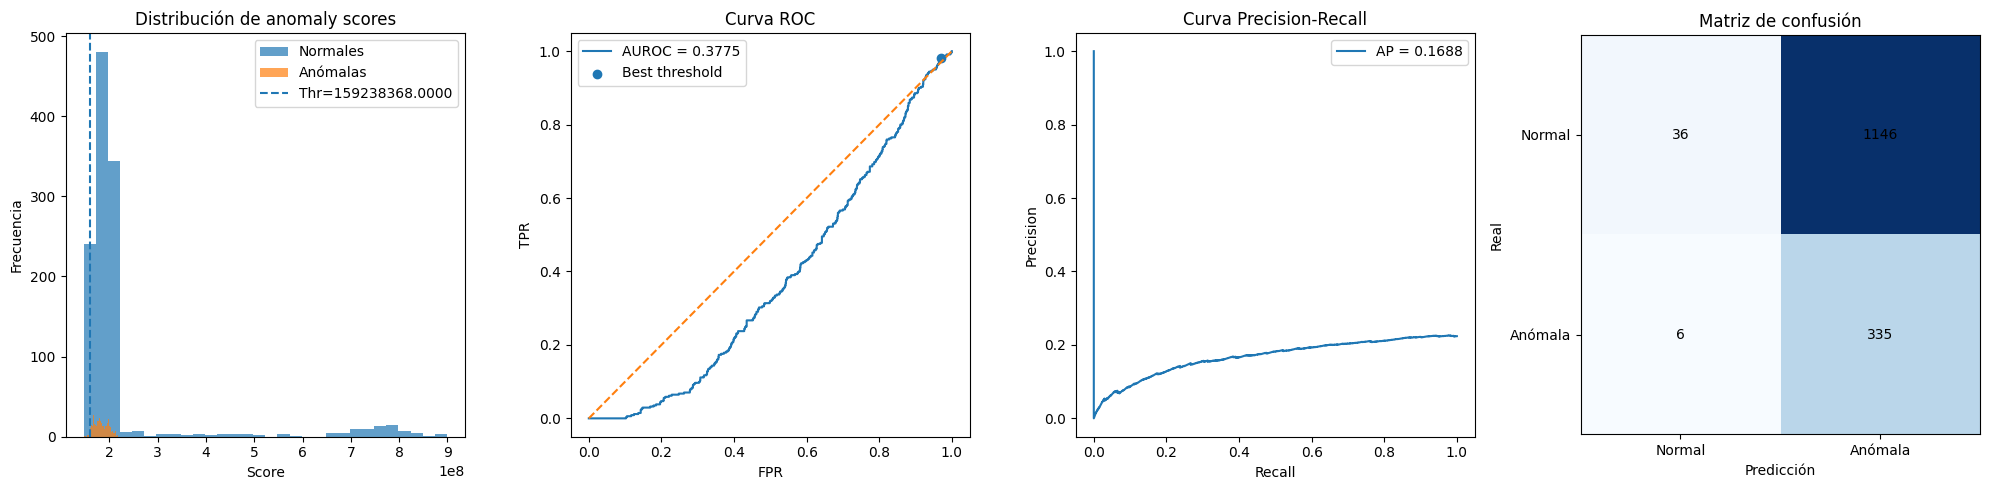

In [22]:
plt.figure(figsize=(20, 5))

# Histograma de scores
plt.subplot(1, 4, 1)
plt.hist(all_scores[all_labels == 0], bins=30, alpha=0.7, label="Normales")
plt.hist(all_scores[all_labels == 1], bins=30, alpha=0.7, label="Anómalas")
plt.axvline(best_threshold, linestyle="--", label=f"Thr={best_threshold:.4f}")
plt.title("Distribución de anomaly scores")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.legend()

# ROC
plt.subplot(1, 4, 2)
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.scatter(fpr[best_idx], tpr[best_idx], label="Best threshold")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(all_labels, all_scores)
plt.subplot(1, 4, 3)
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

# Matriz de confusión visual simple
plt.subplot(1, 4, 4)
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión")
plt.xticks([0, 1], ["Normal", "Anómala"])
plt.yticks([0, 1], ["Normal", "Anómala"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

#VISUALIZACIÓN:

Imagen: /content/drive/MyDrive/datasets/TestBearingPreprocess/NG/2026_04_13_09_29_50_667-ng-0.jpg
Anomaly score           : 201532832.000000
Threshold               : 159238368.000000
Predicción              : ANÓMALA
Prob. estimada anomalía : 100.00%
Prob. estimada normal   : 0.00%


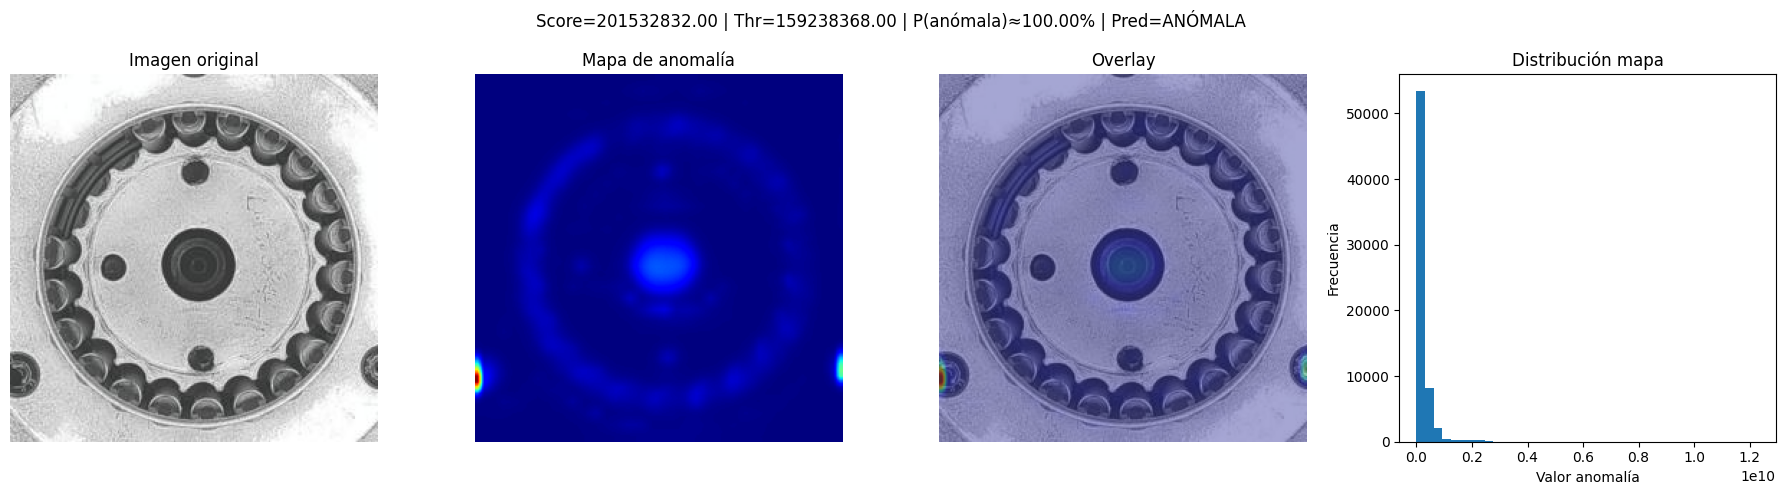

In [33]:
#ruta de la imagen concreta
IMAGE_PATH = "/content/drive/MyDrive/datasets/TestBearingPreprocess/NG/2026_04_13_09_29_50_667-ng-0.jpg"

# Threshold obtenido en validación
BEST_THRESHOLD = float(best_threshold)

# Temperatura para convertir score -> pseudo-probabilidad
SIGMOID_TEMP = 300.0

inference_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# FUNCIÓN SIGMOIDE PARA PSEUDO-PROBABILIDAD
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# CARGAR IMAGEN
pil_img = Image.open(IMAGE_PATH).convert("RGB")
orig_w, orig_h = pil_img.size

img_tensor = inference_transform(pil_img).unsqueeze(0).to(device)

# INFERENCIA
val_model.eval()
with torch.no_grad():
    anomaly_map = val_model.anomaly_map(img_tensor, out_size=(256, 256))  # [1,1,H,W]
    anomaly_score = anomaly_map.flatten(1).topk(100, dim=1).values.mean(dim=1)

# MAPA DE CALOR
heatmap = anomaly_map.squeeze().cpu().numpy()

# Normalizar para visualización
heatmap_norm = heatmap - heatmap.min()
if heatmap_norm.max() > 0:
    heatmap_norm = heatmap_norm / heatmap_norm.max()

heatmap_uint8 = (heatmap_norm * 255).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Imagen original redimensionada al tamaño del mapa
orig_np = np.array(pil_img)

# Superposición
overlay = cv2.addWeighted(orig_np, 0.65, heatmap_color, 0.35, 0)


# PROBABILIDAD ESTIMADA
# Es una transformación suave del score respecto al threshold.
prob_anomaly = sigmoid((anomaly_score - BEST_THRESHOLD) / SIGMOID_TEMP)
prob_normal = 1.0 - prob_anomaly

pred_label = "ANÓMALA" if anomaly_score >= BEST_THRESHOLD else "NORMAL"

print(f"Imagen: {IMAGE_PATH}")
print(f"Anomaly score           : {anomaly_score:.6f}")
print(f"Threshold               : {BEST_THRESHOLD:.6f}")
print(f"Predicción              : {pred_label}")
print(f"Prob. estimada anomalía : {prob_anomaly*100:.2f}%")
print(f"Prob. estimada normal   : {prob_normal*100:.2f}%")

# MOSTRAR RESULTADOS
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(orig_np)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(heatmap_norm, cmap="jet")
plt.title("Mapa de anomalía")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.hist(heatmap.flatten(), bins=40)
plt.title("Distribución mapa")
plt.xlabel("Valor anomalía")
plt.ylabel("Frecuencia")

plt.suptitle(
    f"Score={anomaly_score:.2f} | Thr={BEST_THRESHOLD:.2f} | "
    f"P(anómala)≈{prob_anomaly*100:.2f}% | Pred={pred_label}",
    fontsize=12
)

plt.tight_layout()
plt.show()